# HW5 Offline RL — Report Plots

Generates publication-quality PNG figures from `exp/` logs for Q1 (SAC+BC), Q2 (IQL), and Q3 (FQL).

In [1]:
import os, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 8,
    'legend.title_fontsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'figure.dpi': 120,
    'savefig.dpi': 200,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

EXP_ROOT = Path('../exp')
FIG_DIR  = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

ENV_LABELS = {
    'antmaze-medium-navigate-singletask-task1-v0': 'AntMaze-Medium (debug)',
    'cube-single-play-singletask-task1-v0':        'Cube-Single',
    'antsoccer-arena-navigate-singletask-task1-v0':'AntSoccer-Arena',
}
ALGO_COLORS  = {'sacbc': '#2196F3', 'iql': '#4CAF50', 'fql': '#F44336'}
ALGO_LABELS  = {'sacbc': 'SAC+BC',  'iql': 'IQL',     'fql': 'FQL'}
MAIN_ENVS = [
    'cube-single-play-singletask-task1-v0',
    'antsoccer-arena-navigate-singletask-task1-v0',
]
TARGETS = {
    'cube-single-play-singletask-task1-v0':        {'sacbc': 0.75, 'iql': 0.60, 'fql': 0.80},
    'antsoccer-arena-navigate-singletask-task1-v0':{'sacbc': 0.05, 'iql': 0.05, 'fql': 0.30},
}
TAB10 = plt.get_cmap('tab10')
print('Setup complete.')

Setup complete.


In [2]:
def load_experiments(question):
    deduped = {}
    q_dir = EXP_ROOT / question
    if not q_dir.exists():
        return []
    for exp_dir in sorted(q_dir.iterdir()):
        fp, ep, tp = exp_dir/'flags.json', exp_dir/'eval.csv', exp_dir/'train.csv'
        if not (fp.exists() and ep.exists()):
            continue
        flags = json.loads(fp.read_text())
        r = dict(algo=flags.get('agent'), env=flags.get('env_name'),
                 alpha=flags.get('agent_kwargs', {}).get('alpha'),
                 eval_df=pd.read_csv(ep),
                 train_df=pd.read_csv(tp) if tp.exists() else None,
                 flags=flags, path=exp_dir)
        key = (r['algo'], r['env'], r['alpha'])
        if key not in deduped or len(r['eval_df']) > len(deduped[key]['eval_df']):
            deduped[key] = r
    return list(deduped.values())

def filter_records(records, algo=None, env=None):
    out = [r for r in records
           if (algo is None or r['algo'] == algo)
           and (env  is None or r['env']  == env)]
    return sorted(out, key=lambda r: r['alpha'])

def smooth(y, w=10):
    y = np.array(y)
    if len(y) < w: return y
    return np.convolve(y, np.ones(w)/w, mode='same')

def alpha_cmap(alphas):
    return {a: TAB10(i / max(len(alphas)-1, 1)) for i, a in enumerate(sorted(set(alphas)))}

def is_complete(r):
    return r['eval_df']['step'].max() >= r['flags'].get('training_steps', 1_000_000)

def add_legend_right(ax, title=None):
    """Place legend to the right of an axes, non-overlapping."""
    ax.legend(title=title, loc='upper left', bbox_to_anchor=(1.02, 1),
              borderaxespad=0, framealpha=0.92, handlelength=1.4,
              edgecolor='#cccccc')

def add_target_line(ax, target, env=None):
    ax.axhline(target, ls=':', color='dimgray', lw=1.3, zorder=1)
    ax.text(0.99, target + 0.025, f'target {target:.0%}',
            ha='right', va='bottom', fontsize=7, color='dimgray',
            transform=ax.get_yaxis_transform())

q1_recs = load_experiments('q1')
q2_recs = load_experiments('q2')
q3_recs = load_experiments('q3')
all_recs = q1_recs + q2_recs + q3_recs
print(f'Loaded: Q1={len(q1_recs)}, Q2={len(q2_recs)}, Q3={len(q3_recs)}')
print()
for q, recs in [('Q1', q1_recs), ('Q2', q2_recs), ('Q3', q3_recs)]:
    for r in recs:
        ms = r['eval_df']['step'].max()
        tot = r['flags'].get('training_steps', 1_000_000)
        flag = 'OK' if ms >= tot else f'INCOMPLETE {ms/1e3:.0f}K/{tot/1e3:.0f}K'
        print(f'  [{q}] {r["algo"]:6s} alpha={r["alpha"]:6.1f}  {"-".join(r["env"].split("-")[:2]):20s}  {flag}')

Loaded: Q1=12, Q2=15, Q3=12

  [Q1] sacbc  alpha=   1.0  antmaze-medium        OK
  [Q1] sacbc  alpha=  10.0  antmaze-medium        OK
  [Q1] sacbc  alpha=   3.0  antmaze-medium        OK
  [Q1] sacbc  alpha=  30.0  antmaze-medium        OK
  [Q1] sacbc  alpha= 100.0  cube-single           OK
  [Q1] sacbc  alpha=1000.0  cube-single           OK
  [Q1] sacbc  alpha=  30.0  cube-single           OK
  [Q1] sacbc  alpha= 300.0  cube-single           OK
  [Q1] sacbc  alpha=   1.0  antsoccer-arena       OK
  [Q1] sacbc  alpha=  10.0  antsoccer-arena       OK
  [Q1] sacbc  alpha=   3.0  antsoccer-arena       OK
  [Q1] sacbc  alpha=  30.0  antsoccer-arena       OK
  [Q2] iql    alpha=   1.0  antmaze-medium        OK
  [Q2] iql    alpha=  10.0  antmaze-medium        OK
  [Q2] iql    alpha=   3.0  antmaze-medium        OK
  [Q2] iql    alpha=  30.0  antmaze-medium        OK
  [Q2] iql    alpha= 100.0  cube-single           OK
  [Q2] iql    alpha=1000.0  cube-single           OK
  [Q2] iql    alp

## Q1 — SAC+BC

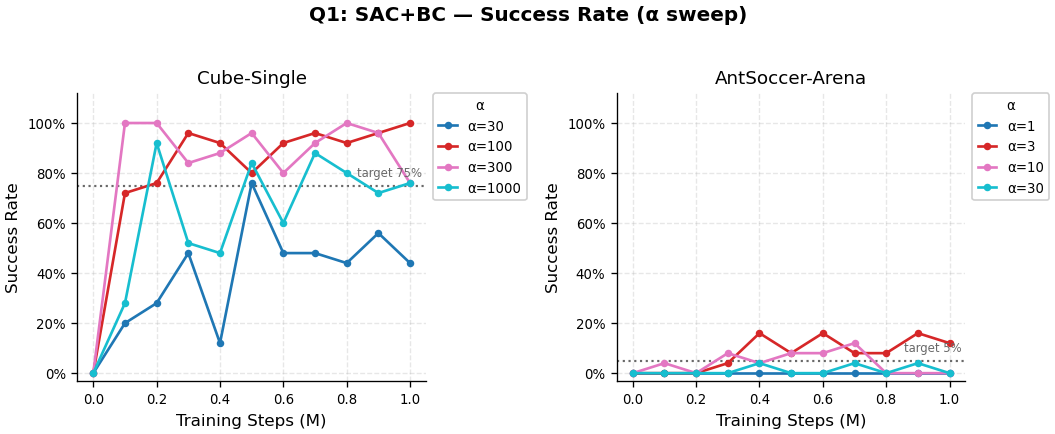

Saved q1_sacbc_success_curves.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, env in zip(axes, MAIN_ENVS):
    recs = filter_records(q1_recs, algo='sacbc', env=env)
    cmap = alpha_cmap([r['alpha'] for r in recs])
    for r in recs:
        df = r['eval_df']
        ax.plot(df['step']/1e6, df['eval/success_rate'],
                color=cmap[r['alpha']], marker='o', ms=3.5, lw=1.6, label=f'\u03b1={r["alpha"]:.0f}')
    add_target_line(ax, TARGETS[env]['sacbc'])
    ax.set_title(ENV_LABELS[env])
    ax.set_xlabel('Training Steps (M)')
    ax.set_ylabel('Success Rate')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_ylim(-0.03, 1.12)
    add_legend_right(ax, title='\u03b1')
fig.suptitle('Q1: SAC+BC — Success Rate (\u03b1 sweep)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'q1_sacbc_success_curves.png')
plt.show()
print('Saved q1_sacbc_success_curves.png')

Best SAC+BC cube-single: alpha=100, final=100%


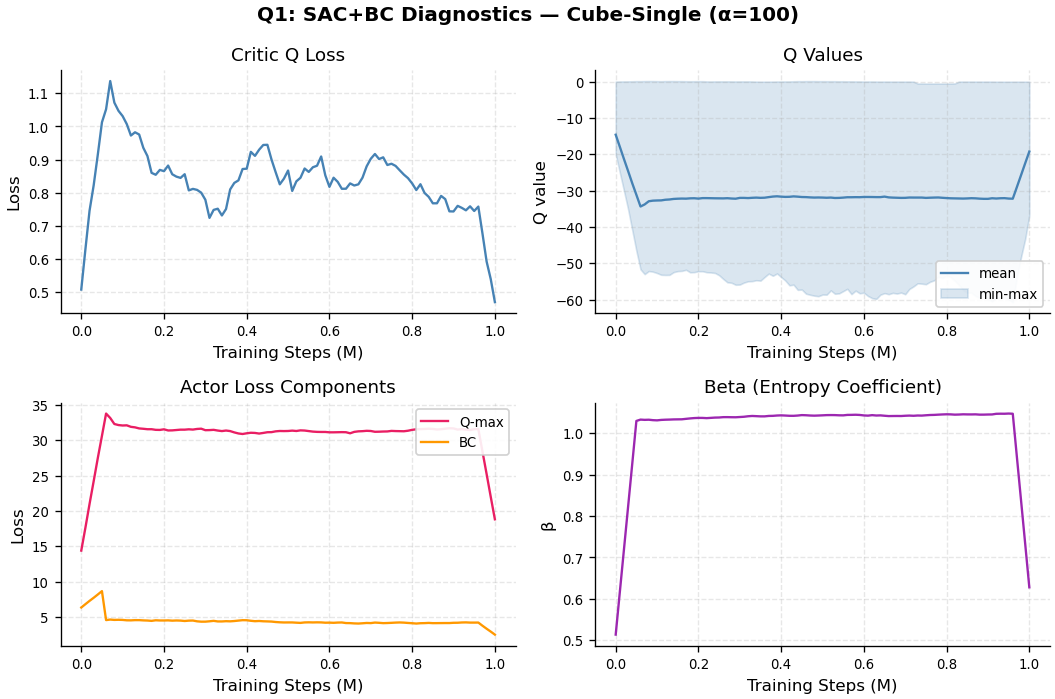

Saved q1_sacbc_diagnostics.png


In [4]:
cube_recs = filter_records(q1_recs, algo='sacbc', env='cube-single-play-singletask-task1-v0')
best_q1 = max(cube_recs, key=lambda r: r['eval_df']['eval/success_rate'].iloc[-1])
print(f'Best SAC+BC cube-single: alpha={best_q1["alpha"]:.0f}, final={best_q1["eval_df"]["eval/success_rate"].iloc[-1]:.0%}')
df, steps, W = best_q1['train_df'], best_q1['train_df']['step']/1e6, 10

fig, axes = plt.subplots(2, 2, figsize=(9, 6))
axes[0,0].plot(steps, smooth(df['critic/q_loss'].values, W), color='steelblue', lw=1.4)
axes[0,0].set_title('Critic Q Loss'); axes[0,0].set_ylabel('Loss')

axes[0,1].plot(steps, smooth(df['critic/q_mean'].values, W), lw=1.4, color='steelblue', label='mean')
axes[0,1].fill_between(steps, smooth(df['critic/q_min'].values, W), smooth(df['critic/q_max'].values, W), alpha=0.2, color='steelblue', label='min-max')
axes[0,1].set_title('Q Values'); axes[0,1].set_ylabel('Q value')
axes[0,1].legend(loc='lower right', framealpha=0.9)

axes[1,0].plot(steps, smooth(df['actor/q_loss'].values, W), lw=1.4, color='#E91E63', label='Q-max')
axes[1,0].plot(steps, smooth(df['actor/bc_loss'].values, W), lw=1.4, color='#FF9800', label='BC')
axes[1,0].set_title('Actor Loss Components'); axes[1,0].set_ylabel('Loss')
axes[1,0].legend(loc='upper right', framealpha=0.9)

axes[1,1].plot(steps, smooth(df['beta/beta'].values, W), lw=1.4, color='#9C27B0')
axes[1,1].set_title('Beta (Entropy Coefficient)'); axes[1,1].set_ylabel('\u03b2')

for ax in axes.flat: ax.set_xlabel('Training Steps (M)')
fig.suptitle(f'Q1: SAC+BC Diagnostics — Cube-Single (\u03b1={best_q1["alpha"]:.0f})', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'q1_sacbc_diagnostics.png')
plt.show()
print('Saved q1_sacbc_diagnostics.png')

## Q2 — IQL

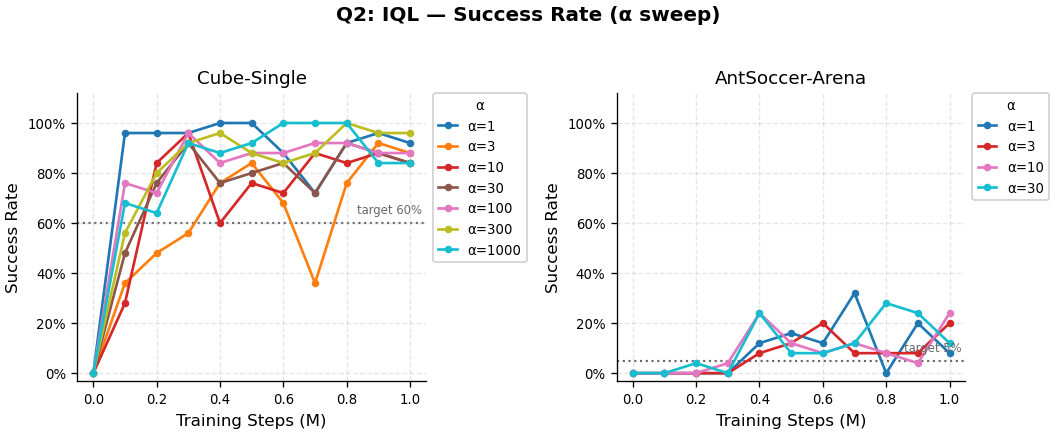

Saved q2_iql_success_curves.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, env in zip(axes, MAIN_ENVS):
    recs = filter_records(q2_recs, algo='iql', env=env)
    if not recs:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(ENV_LABELS[env]); continue
    cmap = alpha_cmap([r['alpha'] for r in recs])
    for r in recs:
        df = r['eval_df']
        incomplete = not is_complete(r)
        ms = df['step'].max()
        lbl = f'\u03b1={r["alpha"]:.0f}' + (f' (⚠{ms/1e3:.0f}K)' if incomplete else '')
        ax.plot(df['step']/1e6, df['eval/success_rate'],
                color=cmap[r['alpha']], marker='o', ms=3.5, lw=1.6,
                ls='--' if incomplete else '-', label=lbl)
    add_target_line(ax, TARGETS[env]['iql'])
    ax.set_title(ENV_LABELS[env])
    ax.set_xlabel('Training Steps (M)'); ax.set_ylabel('Success Rate')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_ylim(-0.03, 1.12)
    add_legend_right(ax, title='\u03b1')
fig.suptitle('Q2: IQL — Success Rate (\u03b1 sweep)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'q2_iql_success_curves.png')
plt.show()
print('Saved q2_iql_success_curves.png')

Best IQL cube-single: alpha=300, final=96%


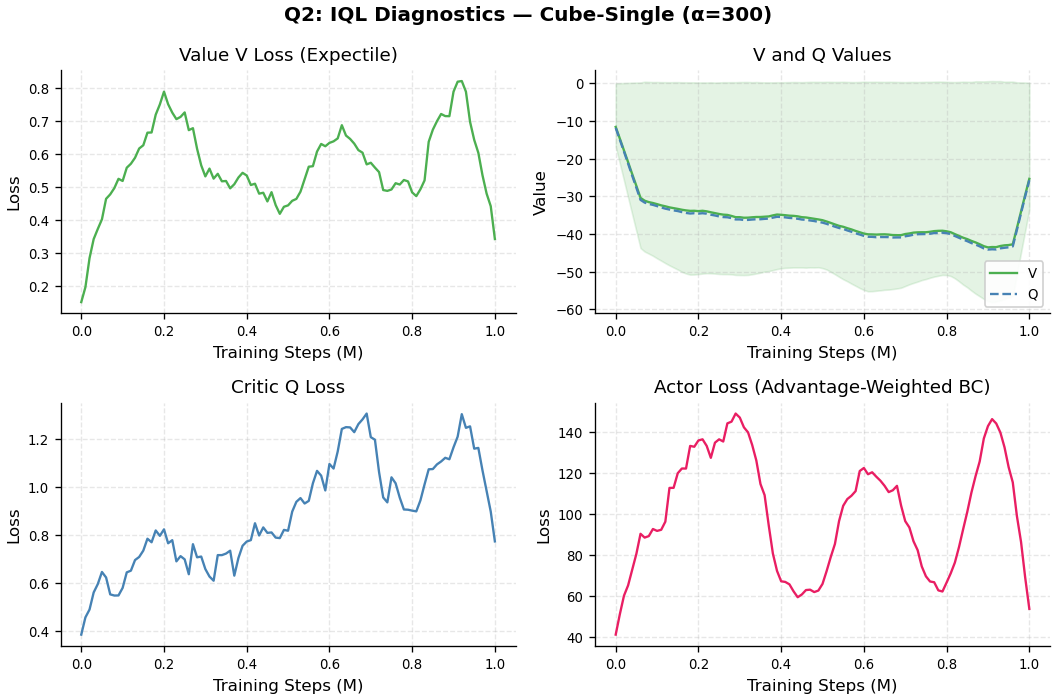

Saved q2_iql_diagnostics.png


In [6]:
cube_recs = filter_records(q2_recs, algo='iql', env='cube-single-play-singletask-task1-v0')
best_q2 = max(cube_recs, key=lambda r: r['eval_df']['eval/success_rate'].iloc[-1])
print(f'Best IQL cube-single: alpha={best_q2["alpha"]:.0f}, final={best_q2["eval_df"]["eval/success_rate"].iloc[-1]:.0%}')
df, steps, W = best_q2['train_df'], best_q2['train_df']['step']/1e6, 10

fig, axes = plt.subplots(2, 2, figsize=(9, 6))
axes[0,0].plot(steps, smooth(df['value/v_loss'].values, W), color='#4CAF50', lw=1.4)
axes[0,0].set_title('Value V Loss (Expectile)'); axes[0,0].set_ylabel('Loss')

axes[0,1].plot(steps, smooth(df['value/v_mean'].values, W), color='#4CAF50', lw=1.4, label='V')
axes[0,1].fill_between(steps, smooth(df['value/v_min'].values, W), smooth(df['value/v_max'].values, W), alpha=0.15, color='#4CAF50')
axes[0,1].plot(steps, smooth(df['critic/q_mean'].values, W), color='steelblue', lw=1.4, ls='--', label='Q')
axes[0,1].set_title('V and Q Values'); axes[0,1].set_ylabel('Value')
axes[0,1].legend(loc='lower right', framealpha=0.9)

axes[1,0].plot(steps, smooth(df['critic/q_loss'].values, W), color='steelblue', lw=1.4)
axes[1,0].set_title('Critic Q Loss'); axes[1,0].set_ylabel('Loss')

axes[1,1].plot(steps, smooth(df['actor/actor_loss'].values, W), color='#E91E63', lw=1.4)
axes[1,1].set_title('Actor Loss (Advantage-Weighted BC)'); axes[1,1].set_ylabel('Loss')

for ax in axes.flat: ax.set_xlabel('Training Steps (M)')
fig.suptitle(f'Q2: IQL Diagnostics — Cube-Single (\u03b1={best_q2["alpha"]:.0f})', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'q2_iql_diagnostics.png')
plt.show()
print('Saved q2_iql_diagnostics.png')

## Q3 — FQL

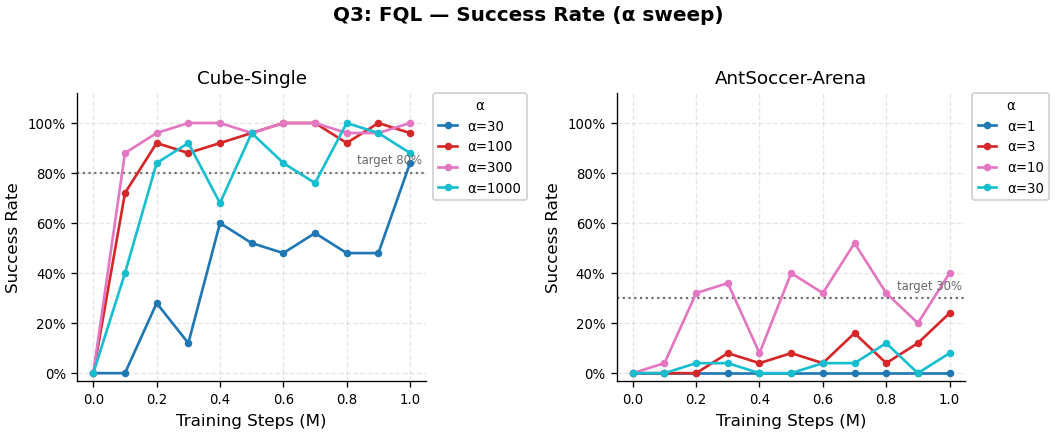

Saved q3_fql_success_curves.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, env in zip(axes, MAIN_ENVS):
    recs = filter_records(q3_recs, algo='fql', env=env)
    cmap = alpha_cmap([r['alpha'] for r in recs])
    for r in recs:
        df = r['eval_df']
        ax.plot(df['step']/1e6, df['eval/success_rate'],
                color=cmap[r['alpha']], marker='o', ms=3.5, lw=1.6, label=f'\u03b1={r["alpha"]:.0f}')
    add_target_line(ax, TARGETS[env]['fql'])
    ax.set_title(ENV_LABELS[env])
    ax.set_xlabel('Training Steps (M)'); ax.set_ylabel('Success Rate')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_ylim(-0.03, 1.12)
    add_legend_right(ax, title='\u03b1')
fig.suptitle('Q3: FQL — Success Rate (\u03b1 sweep)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'q3_fql_success_curves.png')
plt.show()
print('Saved q3_fql_success_curves.png')

Best FQL cube-single: alpha=300, final=100%


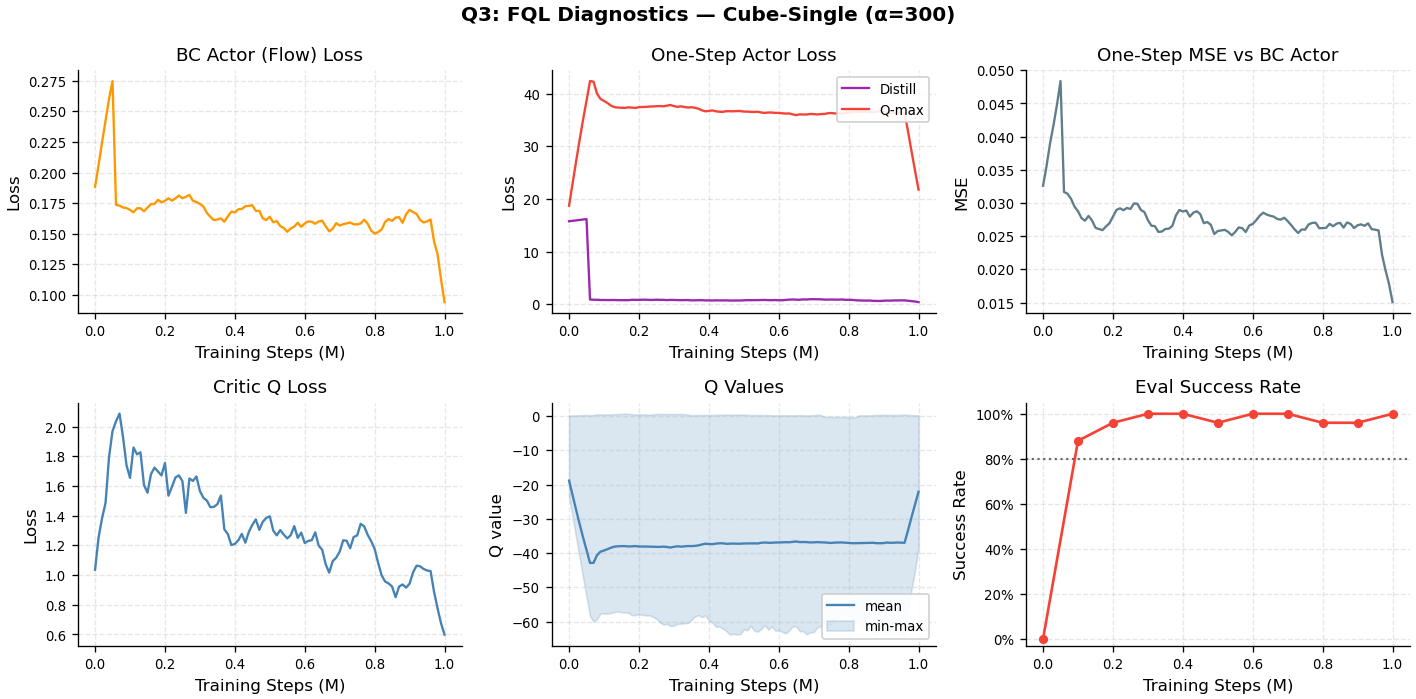

Saved q3_fql_diagnostics.png


In [8]:
cube_recs = filter_records(q3_recs, algo='fql', env='cube-single-play-singletask-task1-v0')
best_q3 = max(cube_recs, key=lambda r: r['eval_df']['eval/success_rate'].iloc[-1])
print(f'Best FQL cube-single: alpha={best_q3["alpha"]:.0f}, final={best_q3["eval_df"]["eval/success_rate"].iloc[-1]:.0%}')
df, steps, W = best_q3['train_df'], best_q3['train_df']['step']/1e6, 10

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes[0,0].plot(steps, smooth(df['bc_actor/loss'].values, W), color='#FF9800', lw=1.4)
axes[0,0].set_title('BC Actor (Flow) Loss'); axes[0,0].set_ylabel('Loss')

axes[0,1].plot(steps, smooth(df['onestep_actor/distill_loss'].values, W), color='#9C27B0', lw=1.4, label='Distill')
axes[0,1].plot(steps, smooth(df['onestep_actor/q_loss'].values, W), color='#F44336', lw=1.4, label='Q-max')
axes[0,1].set_title('One-Step Actor Loss'); axes[0,1].set_ylabel('Loss')
axes[0,1].legend(loc='upper right', framealpha=0.9)

axes[0,2].plot(steps, smooth(df['onestep_actor/mse'].values, W), color='#607D8B', lw=1.4)
axes[0,2].set_title('One-Step MSE vs BC Actor'); axes[0,2].set_ylabel('MSE')

axes[1,0].plot(steps, smooth(df['critic/q_loss'].values, W), color='steelblue', lw=1.4)
axes[1,0].set_title('Critic Q Loss'); axes[1,0].set_ylabel('Loss')

axes[1,1].plot(steps, smooth(df['critic/q_mean'].values, W), color='steelblue', lw=1.4, label='mean')
axes[1,1].fill_between(steps, smooth(df['critic/q_min'].values, W), smooth(df['critic/q_max'].values, W), alpha=0.2, color='steelblue', label='min-max')
axes[1,1].set_title('Q Values'); axes[1,1].set_ylabel('Q value')
axes[1,1].legend(loc='lower right', framealpha=0.9)

eval_df = best_q3['eval_df']
axes[1,2].plot(eval_df['step']/1e6, eval_df['eval/success_rate'], color='#F44336', marker='o', ms=4.5, lw=1.6)
axes[1,2].axhline(TARGETS['cube-single-play-singletask-task1-v0']['fql'], ls=':', color='dimgray', lw=1.3)
axes[1,2].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1,2].set_title('Eval Success Rate'); axes[1,2].set_ylabel('Success Rate'); axes[1,2].set_ylim(-0.03, 1.05)

for ax in axes.flat: ax.set_xlabel('Training Steps (M)')
fig.suptitle(f'Q3: FQL Diagnostics — Cube-Single (\u03b1={best_q3["alpha"]:.0f})', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'q3_fql_diagnostics.png')
plt.show()
print('Saved q3_fql_diagnostics.png')

## Cross-Algorithm Comparison

In [9]:
def best_run(algo, env):
    recs = filter_records(all_recs, algo=algo, env=env)
    return max(recs, key=lambda r: r['eval_df']['eval/success_rate'].iloc[-1]) if recs else None

print(f'{"Algorithm":10s}  {"Environment":40s}  {"Best alpha":10s}  {"Final":8s}')
print('-' * 75)
for algo, label in ALGO_LABELS.items():
    for env in MAIN_ENVS:
        r = best_run(algo, env)
        if r:
            final = r['eval_df']['eval/success_rate'].iloc[-1]
            ms = r['eval_df']['step'].max()
            tot = r['flags'].get('training_steps', 1_000_000)
            flag = '' if ms >= tot else f' (incomplete {ms/1e3:.0f}K)'
            print(f'{label:10s}  {ENV_LABELS[env]:40s}  {r["alpha"]:10.0f}  {final:7.0%}{flag}')

Algorithm   Environment                               Best alpha  Final   
---------------------------------------------------------------------------
SAC+BC      Cube-Single                                      100     100%
SAC+BC      AntSoccer-Arena                                    3      12%
IQL         Cube-Single                                      300      96%
IQL         AntSoccer-Arena                                   10      24%
FQL         Cube-Single                                      300     100%
FQL         AntSoccer-Arena                                   10      40%


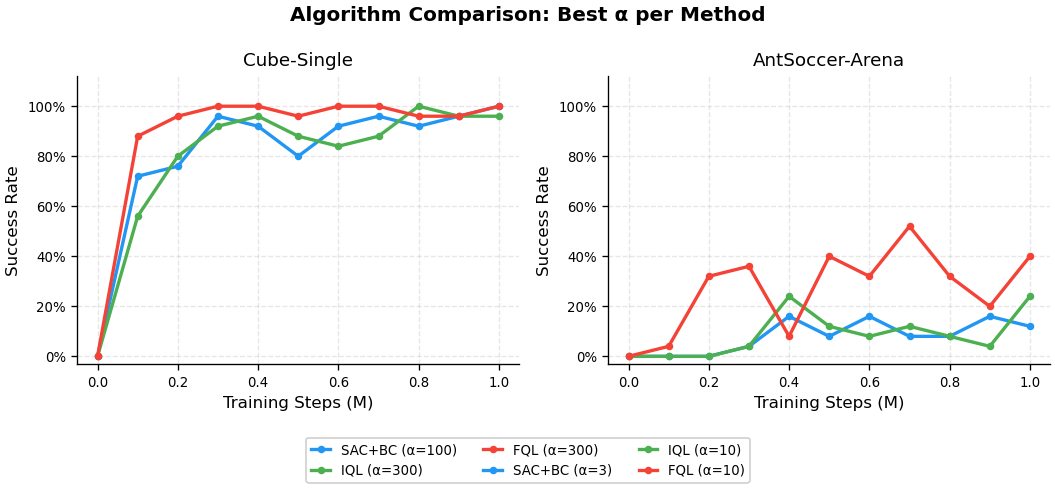

Saved comparison_all_algorithms.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, env in zip(axes, MAIN_ENVS):
    for algo, label in ALGO_LABELS.items():
        r = best_run(algo, env)
        if r is None: continue
        df = r['eval_df']
        incomplete = not is_complete(r)
        ms = df['step'].max()
        lbl = f'{label} (\u03b1={r["alpha"]:.0f})' + (f' \u26a0{ms/1e3:.0f}K' if incomplete else '')
        ax.plot(df['step']/1e6, df['eval/success_rate'],
                color=ALGO_COLORS[algo], marker='o', ms=3.5, lw=2,
                ls='--' if incomplete else '-', label=lbl)
    ax.set_title(ENV_LABELS[env])
    ax.set_xlabel('Training Steps (M)'); ax.set_ylabel('Success Rate')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_ylim(-0.03, 1.12)

# Shared legend below figure
handles, labels = [], []
for ax in axes:
    for h, l in zip(*ax.get_legend_handles_labels()):
        if l not in labels:
            handles.append(h); labels.append(l)
fig.legend(handles, labels, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.14), framealpha=0.92, handlelength=1.4, fontsize=8)
fig.suptitle('Algorithm Comparison: Best \u03b1 per Method', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'comparison_all_algorithms.png')
plt.show()
print('Saved comparison_all_algorithms.png')

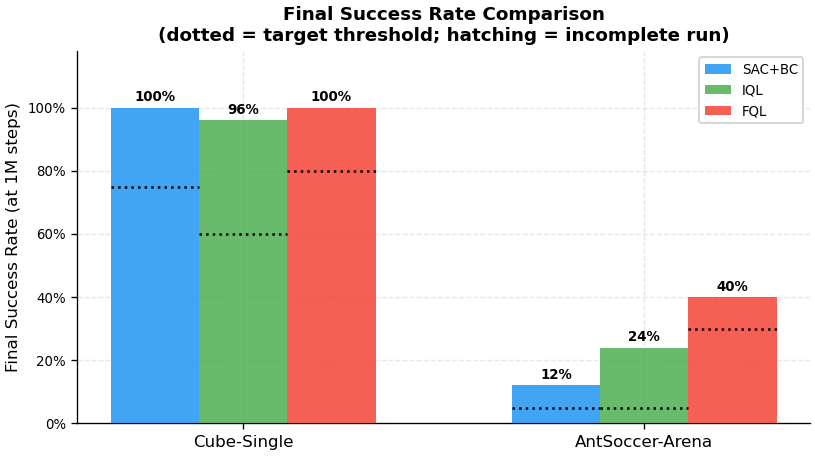

Saved comparison_bar_chart.png


In [11]:
ENV_SHORT = {'cube-single-play-singletask-task1-v0': 'Cube-Single',
             'antsoccer-arena-navigate-singletask-task1-v0': 'AntSoccer-Arena'}
algos = list(ALGO_LABELS.keys())
envs  = list(ENV_SHORT.keys())
x, width = np.arange(len(envs)), 0.22

fig, ax = plt.subplots(figsize=(7, 4))
for i, algo in enumerate(algos):
    vals, flags = [], []
    for env in envs:
        r = best_run(algo, env)
        vals.append(r['eval_df']['eval/success_rate'].iloc[-1] if r else 0.0)
        flags.append(r is not None and not is_complete(r))
    bars = ax.bar(x + (i-1)*width, vals, width, label=ALGO_LABELS[algo],
                  color=ALGO_COLORS[algo], alpha=0.85, zorder=3)
    for bar, val, flag in zip(bars, vals, flags):
        if flag:
            bar.set_hatch('///')
            bar.set_edgecolor('black')
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.0%}', ha='center', va='bottom', fontsize=8, fontweight='bold')

for i_env, env in enumerate(envs):
    for i_algo, algo in enumerate(algos):
        t = TARGETS[env][algo]
        bx = x[i_env] + (i_algo-1)*width
        ax.plot([bx - width/2, bx + width/2], [t, t], color='black', lw=1.5, ls=':', zorder=4)

ax.set_xticks(x); ax.set_xticklabels(list(ENV_SHORT.values()), fontsize=10)
ax.set_ylabel('Final Success Rate (at 1M steps)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_ylim(0, 1.18)
ax.legend(loc='upper right', framealpha=0.9)
ax.set_title('Final Success Rate Comparison\n(dotted = target threshold; hatching = incomplete run)', fontweight='bold')
ax.grid(axis='y', alpha=0.3, ls='--'); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig(FIG_DIR / 'comparison_bar_chart.png')
plt.show()
print('Saved comparison_bar_chart.png')

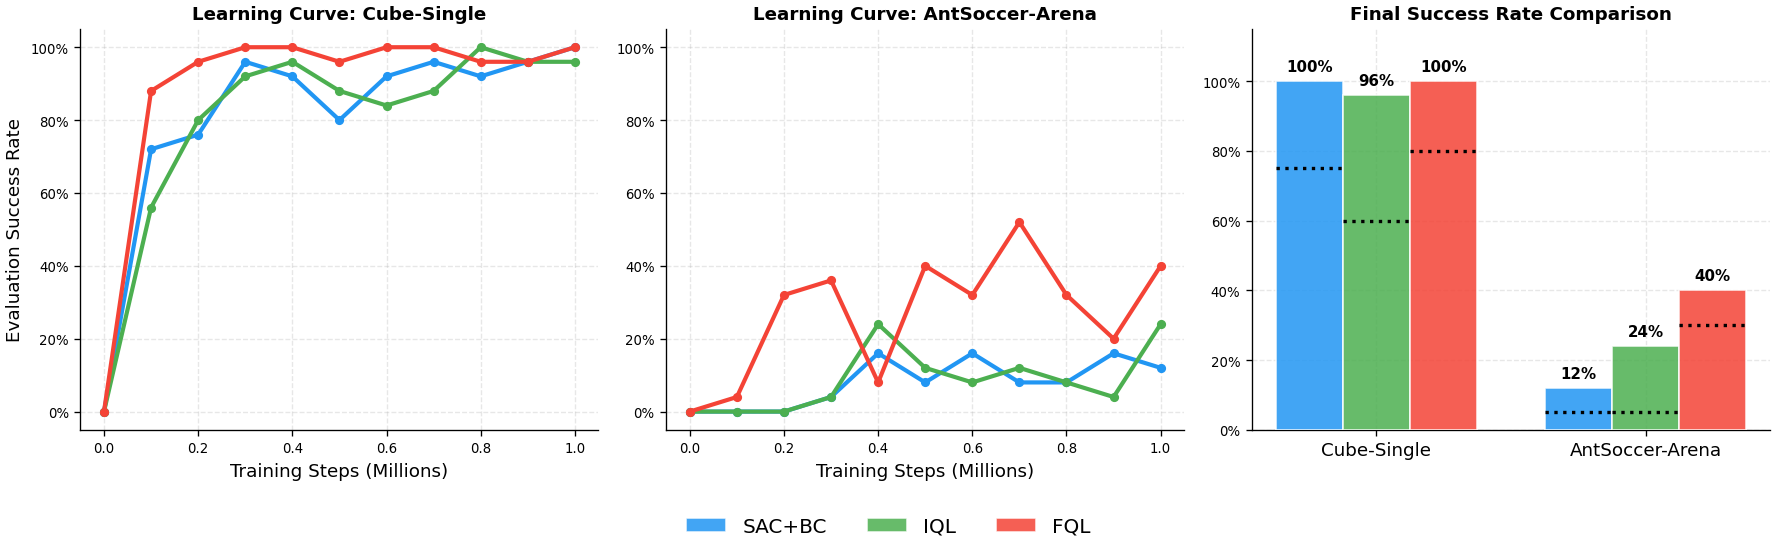

Saved comparison_all_combined.png


In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# --- 1. Setup Figure ---
# A 1x3 grid gives us equal space for the two learning curves and the bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# --- 2. Plot Learning Curves (Axes 0 & 1) ---
for i, env in enumerate(MAIN_ENVS):
    ax = axes[i]
    for algo, label in ALGO_LABELS.items():
        r = best_run(algo, env)
        if r is None: continue
        
        df = r['eval_df']
        incomplete = not is_complete(r)
        
        # Plot lines with slightly larger markers
        ax.plot(df['step'] / 1e6, df['eval/success_rate'],
                color=ALGO_COLORS[algo], marker='o', ms=4.5, lw=2.5,
                ls='--' if incomplete else '-', label=label) # Using just the label for the shared legend
        
    ax.set_title(f'Learning Curve: {ENV_SHORT.get(env, env)}', fontweight='bold')
    ax.set_xlabel('Training Steps (Millions)', fontsize=11)
    if i == 0:
        ax.set_ylabel('Evaluation Success Rate', fontsize=11)
        
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_ylim(-0.05, 1.05)
    
    # Add subtle gridlines for readability
    ax.grid(True, alpha=0.3, ls='--')
    ax.set_axisbelow(True)

# --- 3. Plot Bar Chart (Axis 2) ---
ax_bar = axes[2]
algos = list(ALGO_LABELS.keys())
envs = list(ENV_SHORT.keys())

x = np.arange(len(envs))
width = 0.25 # Set width so 3 bars fit nicely (0.25 * 3 = 0.75)

for i, algo in enumerate(algos):
    vals, flags = [], []
    for env in envs:
        r = best_run(algo, env)
        vals.append(r['eval_df']['eval/success_rate'].iloc[-1] if r else 0.0)
        flags.append(r is not None and not is_complete(r))
    
    # Center the grouped bars: offset is -width, 0, or +width for 3 algorithms
    offset = (i - 1) * width
    bars = ax_bar.bar(x + offset, vals, width, label=ALGO_LABELS[algo],
                      color=ALGO_COLORS[algo], alpha=0.85, edgecolor='white', zorder=3)
    
    # Annotate bars
    for bar, val, flag in zip(bars, vals, flags):
        if flag:
            bar.set_hatch('///')
            bar.set_edgecolor('black')
        
        # Display the % value above the bar
        ax_bar.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                    f'{val:.0%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot target lines
for i_env, env in enumerate(envs):
    for i_algo, algo in enumerate(algos):
        t = TARGETS[env][algo]
        bx = x[i_env] + (i_algo - 1) * width
        ax_bar.plot([bx - width/2, bx + width/2], [t, t], color='black', lw=2, ls=':', zorder=4)

ax_bar.set_xticks(x)
ax_bar.set_xticklabels(list(ENV_SHORT.values()), fontsize=11)
ax_bar.set_title('Final Success Rate Comparison', fontweight='bold')
ax_bar.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax_bar.set_ylim(0, 1.15) # Extra headroom for text labels
ax_bar.grid(axis='y', alpha=0.3, ls='--')
ax_bar.set_axisbelow(True)

# --- 4. Shared Legend & Final Polish ---
# Extract handles from the bar chart (since they represent the clean algorithm names)
handles, labels = ax_bar.get_legend_handles_labels()

# Place a single legend spanning across the bottom of the entire figure
fig.legend(handles, labels, loc='lower center', ncol=3, 
           bbox_to_anchor=(0.5, -0.05), frameon=False, fontsize=12)

# Adjust layout to make room for the bottom legend
plt.tight_layout()
fig.subplots_adjust(bottom=0.18) 

plt.savefig(FIG_DIR / 'comparison_all_combined.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved comparison_all_combined.png')

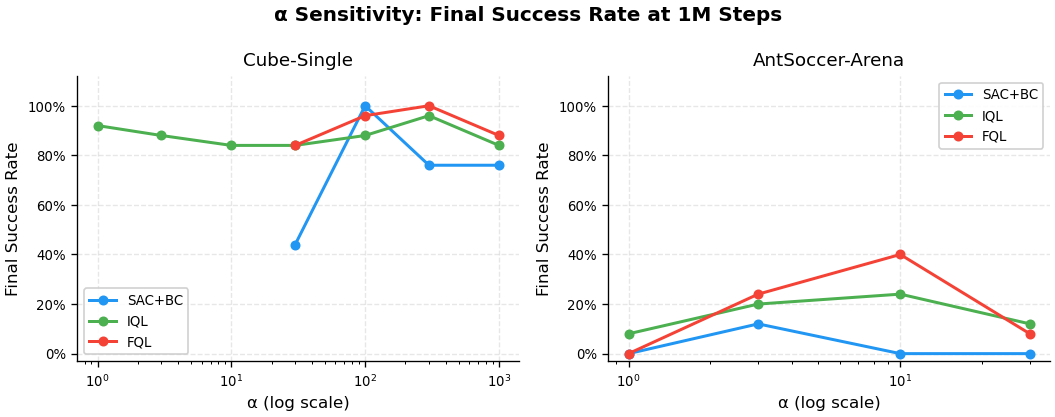

Saved alpha_sensitivity.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
Q_RECS = [('sacbc', q1_recs), ('iql', q2_recs), ('fql', q3_recs)]
for ax, env in zip(axes, MAIN_ENVS):
    for algo, recs in Q_RECS:
        runs = filter_records(recs, algo=algo, env=env)
        if not runs: continue
        pairs = sorted((r['alpha'], r['eval_df']['eval/success_rate'].iloc[-1]) for r in runs)
        ax.plot([p[0] for p in pairs], [p[1] for p in pairs],
                color=ALGO_COLORS[algo], marker='o', ms=5, lw=1.8, label=ALGO_LABELS[algo])
    ax.set_title(ENV_LABELS[env])
    ax.set_xlabel('\u03b1 (log scale)'); ax.set_ylabel('Final Success Rate')
    ax.set_xscale('log')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.set_ylim(-0.03, 1.12)
    ax.legend(loc='best', framealpha=0.9)
fig.suptitle('\u03b1 Sensitivity: Final Success Rate at 1M Steps', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'alpha_sensitivity.png')
plt.show()
print('Saved alpha_sensitivity.png')

In [13]:
print('\nAll saved figures:')
for f in sorted(FIG_DIR.glob('*.png')):
    print(f'  {f.name:45s} {f.stat().st_size//1024:4d} KB')


All saved figures:
  alpha_sensitivity.png                          111 KB
  comparison_all_algorithms.png                  142 KB
  comparison_bar_chart.png                        80 KB
  q1_sacbc_diagnostics.png                       198 KB
  q1_sacbc_success_curves.png                    157 KB
  q2_iql_diagnostics.png                         233 KB
  q2_iql_success_curves.png                      181 KB
  q3_fql_diagnostics.png                         289 KB
  q3_fql_success_curves.png                      156 KB
